In [86]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [87]:
# Cargar paquetes
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import shapiro, skew, kurtosis
from scipy import stats

In [88]:
df = pd.read_csv(r'D:\ydiazn\Documents\Ciencia_Datos_con_Python\test\Proyecto\DataAjuste.csv', 
                 encoding='cp1252', sep=';',decimal=',')
df.head()

C:\Users\ydiazn\AppData\Local\Temp\ipykernel_1900\1509165279.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'D:\ydiazn\Documents\Ciencia_Datos_con_Python\test\Proyecto\DataAjuste.csv',


,CUENTA,CICLO,MUNICIPIO,SUBCATEGORIA,PLAN_FACTURACION,FACTURACION_PROMEDIO,M3_PROMEDIO,VALOR_PAGO_PROMEDIO,FACTURACION_PERIODO,M3_PERIODO,CANTIDAD_AJUSTES_ULT_6_MESES,VALOR_AJUSTE_PROMEDIO,AJUSTE_PERIODO,AJUSTE_EN_ULT_6_MESES
0,906655,PLB - PC,PC,Residencial 3,AGUA Y/O ALCANTARILLADO,99603114.83,18862.83,6929491.0,75625702,14723.0,1,1.240630e+09,0,1
1,898861,Z11 - BQ,BQ,Residencial 4,AGUA Y/O ALCANTARILLADO,50842636.83,9456.83,2883459.0,5787962,455.0,0,0.000000e+00,0,0
2,906232,Z45 - BQ,BQ,Residencial 1,AGUA Y/O ALCANTARILLADO VIP,36374402.33,7131.00,0.0,27299245,5305.0,1,1.531600e+04,0,1
3,764220,Z55 - BQ,BQ,Residencial 6,AGUA Y/O ALCANTARILLADO,36346688.83,4037.33,31480670.5,85010329,4155.0,2,4.721226e+07,0,1
4,848055,5 - TUB,TUB,Residencial 4,AGUA Y/O ALCANTARILLADO,31770756.17,5402.17,0.0,43448126,7402.0,2,1.401509e+06,0,1


In [89]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677507 entries, 0 to 677506
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   CUENTA                        677507 non-null  int64  
 1   CICLO                         677507 non-null  object 
 2   MUNICIPIO                     677507 non-null  object 
 3   SUBCATEGORIA                  676564 non-null  object 
 4   PLAN_FACTURACION              677507 non-null  object 
 5   FACTURACION_PROMEDIO          677507 non-null  object 
 6   M3_PROMEDIO                   677507 non-null  float64
 7   VALOR_PAGO_PROMEDIO           677507 non-null  float64
 8   FACTURACION_PERIODO           677507 non-null  int64  
 9   M3_PERIODO                    677507 non-null  float64
 10  CANTIDAD_AJUSTES_ULT_6_MESES  677507 non-null  int64  
 11  VALOR_AJUSTE_PROMEDIO         677507 non-null  float64
 12  AJUSTE_PERIODO                677507 non-nul

In [90]:
print(df.columns.tolist())

['CUENTA', 'CICLO', 'MUNICIPIO', 'SUBCATEGORIA', 'PLAN_FACTURACION', 'FACTURACION_PROMEDIO', 'M3_PROMEDIO', 'VALOR_PAGO_PROMEDIO', 'FACTURACION_PERIODO', 'M3_PERIODO', 'CANTIDAD_AJUSTES_ULT_6_MESES', 'VALOR_AJUSTE_PROMEDIO', 'AJUSTE_PERIODO', 'AJUSTE_EN_ULT_6_MESES']


In [135]:
columnas = [
    'FACTURACION_PROMEDIO',
    'M3_PROMEDIO',
    'VALOR_PAGO_PROMEDIO',
    'FACTURACION_PERIODO',
    'M3_PERIODO',
    'VALOR_AJUSTE_PROMEDIO']

for col in columnas:
    df[col] = df[col].astype(str).str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['CUENTA'] = df['CUENTA'].astype(str)
df['AJUSTE_EN_ULT_6_MESES'] = df['AJUSTE_EN_ULT_6_MESES'].astype('category')

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677507 entries, 0 to 677506
Data columns (total 15 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   CUENTA                        677507 non-null  object  
 1   CICLO                         677507 non-null  object  
 2   MUNICIPIO                     677507 non-null  object  
 3   SUBCATEGORIA                  676564 non-null  object  
 4   PLAN_FACTURACION              677507 non-null  object  
 5   FACTURACION_PROMEDIO          676417 non-null  float64 
 6   M3_PROMEDIO                   677507 non-null  float64 
 7   VALOR_PAGO_PROMEDIO           677507 non-null  float64 
 8   FACTURACION_PERIODO           677507 non-null  int64   
 9   M3_PERIODO                    677507 non-null  float64 
 10  CANTIDAD_AJUSTES_ULT_6_MESES  677507 non-null  int64   
 11  VALOR_AJUSTE_PROMEDIO         677507 non-null  float64 
 12  AJUSTE_PERIODO                

In [92]:
# conteo
df['AJUSTE_EN_ULT_6_MESES'].value_counts() 

AJUSTE_EN_ULT_6_MESES
0    626913
1     50594
Name: count, dtype: int64

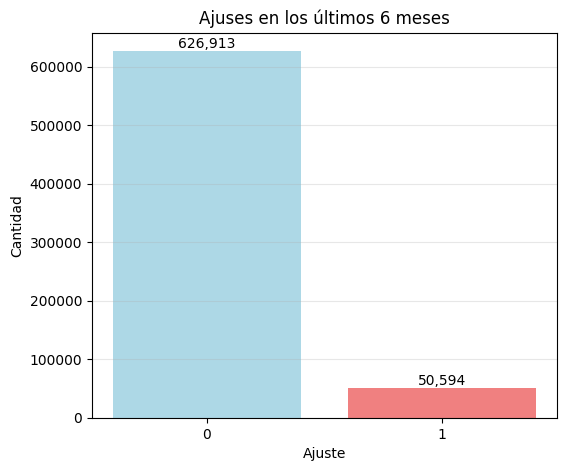

In [93]:
# Contar el tipo de tienda
tipo = df['AJUSTE_EN_ULT_6_MESES'].value_counts()
plt.figure(figsize=(6, 5))

# Graficar el conteo de tipos de tienda en un gráfico de barras verticales
barras = plt.bar(tipo.index, tipo.values, color=['lightblue', 'lightcoral'])

# Agregar valores encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura,
        f'{int(altura):,}',
        ha='center', va='bottom',
        fontsize=10#, fontweight='bold'
    )

plt.xlabel('Ajuste')
plt.ylabel('Cantidad')
plt.title('Ajuses en los últimos 6 meses')

# Mostrar únicamente 0 y 1 en eje X
plt.xticks(
    ticks=range(len(tipo)),
    labels=tipo.index.astype(str))

plt.grid(axis='y', alpha=0.3)
plt.show()

In [94]:
# Proporciones
df['AJUSTE_EN_ULT_6_MESES'].value_counts(normalize=True)*100

AJUSTE_EN_ULT_6_MESES
0    92.532328
1     7.467672
Name: proportion, dtype: float64

In [95]:
# Conteo de categorías
proporcion = (df['AJUSTE_EN_ULT_6_MESES'].value_counts().sort_index().reset_index())

proporcion.columns = ['Ajuste', 'Cantidad']

# Etiquetas descriptivas
proporcion['Ajuste'] = proporcion['Ajuste'].map({
    0: 'Sin ajuste',
    1: 'Con ajuste'})

# Gráfico interactivo
fig = px.pie(
    proporcion,
    names='Ajuste', values='Cantidad',
    title='Proporción de ajustes en los últimos 6 meses',
    hole=0.45  # tipo dona
    )

fig.update_traces(
    textposition='inside', textinfo='percent+label',
    hovertemplate=
    '<b>%{label}</b><br>' +
    'Cantidad: %{value:,}<br>' +
    'Porcentaje: %{percent}<extra></extra>')

fig.update_layout(template='plotly_white', width=600, height=500,
    legend_title='Estado')

fig.show()

In [96]:
# Descriptivo de una sola variable categórica solo conteo
conteo = df['AJUSTE_EN_ULT_6_MESES'].value_counts()

# Descriptivo de una sola variable categórica solo proporcion
porcentajes = df['AJUSTE_EN_ULT_6_MESES'].value_counts(normalize=True)*100

# Combinar los resultados en un solo DataFrame
resultado = pd.DataFrame({
    'Conteo': conteo,
    'Proporción': porcentajes
})

# imprimir
print(resultado)

                       Conteo  Proporción
AJUSTE_EN_ULT_6_MESES                    
0                      626913   92.532328
1                       50594    7.467672


**Veamos la variable de Categoria para conocer la incidencia en la variable respuesta**

In [97]:
# Descriptivo de una sola variable categórica solo conteo
conteo = df['SUBCATEGORIA'].value_counts()

# Descriptivo de una sola variable categórica solo proporcion
porcentajes = df['SUBCATEGORIA'].value_counts(normalize=True)*100

# Combinar los resultados en un solo DataFrame
resultado = pd.DataFrame({
    'Conteo': conteo,
    'Proporción': porcentajes
})

# imprimir
print(resultado)

               Conteo  Proporción
SUBCATEGORIA                     
Residencial 1  258255   38.171555
Residencial 2  206662   30.545817
Residencial 3  116511   17.220987
Residencial 4   59849    8.846022
Residencial 5   20725    3.063273
Residencial 6   14562    2.152346


In [98]:
# Descriptivo de una sola variable categórica solo conteo
conteo = df['PLAN_FACTURACION'].value_counts()

# Descriptivo de una sola variable categórica solo proporcion
porcentajes = df['PLAN_FACTURACION'].value_counts(normalize=True)*100

# Combinar los resultados en un solo DataFrame
resultado = pd.DataFrame({
    'Conteo': conteo,
    'Proporción': porcentajes
})

# imprimir
print(resultado)

                                                    Conteo  Proporción
PLAN_FACTURACION                                                      
AGUA Y/O ALCANTARILLADO                             613583   90.564821
MULTIUSUARIO AGUA Y/O ALCANTARILLADO                 26599    3.926011
ASEO URBANO                                          16322    2.409126
AGUA Y/O ALCANTARILLADO VIP                          11269    1.663304
AGUA Y/O ALCANTARILLADO CARGO FIJO                    5305    0.783018
HOGARES ICBF AGUA Y/O ALCANTARILLADO                  2569    0.379184
AGUA SIN CARGOS EN FACTURA RECURRENTE                  355    0.052398
MULTIUSUARIO AGUA PRODUCTO BASE                        300    0.044280
PATRIMONIO HISTÓRICO AGUA Y/O ALCANTARILLADO           279    0.041180
COBRO DE SERVICIOS                                     259    0.038228
MULTIUSUARIO AGUA ICBF                                 195    0.028782
HOGARES ICBF ASEO URBANO                               194    0.028634
MULTIU

**ANALISIS PARA LAS VARIABLES NUMERICAS**

In [99]:
df['FACTURACION_PROMEDIO'].mean()

65431.16597337144

In [100]:
# Construir la serie con todos los estadísticos
estadisticos = pd.Series({
    'Media': df['FACTURACION_PROMEDIO'].mean() ,
    'Desviación Estándar': df['FACTURACION_PROMEDIO'].std() , #Recomendable 20% hacia abajo
    'Mediana': df['FACTURACION_PROMEDIO'].median() ,
    'Primer Cuartil (Q1)': df['FACTURACION_PROMEDIO'].quantile(0.25) ,
    'Tercer Cuartil (Q3)': df['FACTURACION_PROMEDIO'].quantile(0.75) ,
    'Rango Intercuartílico (IQR)': df['FACTURACION_PROMEDIO'].quantile(0.75) - df['FACTURACION_PROMEDIO'].quantile(0.25) ,
    'Mínimo': df['FACTURACION_PROMEDIO'].min() ,
    'Máximo': df['FACTURACION_PROMEDIO'].max() ,
   
    #Para saber si aplico o no aplico transformación
    'Coeficiente de Asimetría': df['FACTURACION_PROMEDIO'].skew() ,  #Qué tan asimétrico se encuentran los datos
    #Positivo: Cola hacia la derecha. Negativo: Cola hacia la izquiera
    'Curtosis': df['FACTURACION_PROMEDIO'].kurt()  #Qué tan puntiaguda o llana es la campana
    #Leptocurtica: No hay tanta desviación de los datos, se concentran en el promedio
    #Platicurtica: Se encuentra alejado del promedio
})
 
print(estadisticos)
 

Media                          6.543117e+04
Desviación Estándar            2.101646e+05
Mediana                        4.984891e+04
Primer Cuartil (Q1)            3.053917e+04
Tercer Cuartil (Q3)            7.488700e+04
Rango Intercuartílico (IQR)    4.434783e+04
Mínimo                        -3.630000e+02
Máximo                         9.960311e+07
Coeficiente de Asimetría       2.208363e+02
Curtosis                       8.478131e+04
dtype: float64


In [101]:
# Construir la serie con todos los estadísticos
estadisticos = pd.Series({
    'Media': df['M3_PROMEDIO'].mean() ,
    'Desviación Estándar': df['M3_PROMEDIO'].std() , #Recomendable 20% hacia abajo
    'Mediana': df['M3_PROMEDIO'].median() ,
    'Primer Cuartil (Q1)': df['M3_PROMEDIO'].quantile(0.25) ,
    'Tercer Cuartil (Q3)': df['M3_PROMEDIO'].quantile(0.75) ,
    'Rango Intercuartílico (IQR)': df['M3_PROMEDIO'].quantile(0.75) - df['M3_PROMEDIO'].quantile(0.25) ,
    'Mínimo': df['M3_PROMEDIO'].min() ,
    'Máximo': df['M3_PROMEDIO'].max() ,
   
    #Para saber si aplico o no aplico transformación
    'Coeficiente de Asimetría': df['M3_PROMEDIO'].skew() ,  #Qué tan asimétrico se encuentran los datos
    #Positivo: Cola hacia la derecha. Negativo: Cola hacia la izquiera
    'Curtosis': df['M3_PROMEDIO'].kurt()  #Qué tan puntiaguda o llana es la campana
    #Leptocurtica: No hay tanta desviación de los datos, se concentran en el promedio
    #Platicurtica: Se encuentra alejado del promedio
})
 
print(estadisticos)
 

Media                             11.648139
Desviación Estándar               44.647259
Mediana                            9.330000
Primer Cuartil (Q1)                4.830000
Tercer Cuartil (Q3)               16.000000
Rango Intercuartílico (IQR)       11.170000
Mínimo                             0.000000
Máximo                         18862.830000
Coeficiente de Asimetría         262.042866
Curtosis                       98690.132734
dtype: float64


In [102]:
# Construir la serie con todos los estadísticos
estadisticos = pd.Series({
    'Media': df['VALOR_PAGO_PROMEDIO'].mean() ,
    'Desviación Estándar': df['VALOR_PAGO_PROMEDIO'].std() , #Recomendable 20% hacia abajo
    'Mediana': df['VALOR_PAGO_PROMEDIO'].median() ,
    'Primer Cuartil (Q1)': df['VALOR_PAGO_PROMEDIO'].quantile(0.25) ,
    'Tercer Cuartil (Q3)': df['VALOR_PAGO_PROMEDIO'].quantile(0.75) ,
    'Rango Intercuartílico (IQR)': df['VALOR_PAGO_PROMEDIO'].quantile(0.75) - df['VALOR_PAGO_PROMEDIO'].quantile(0.25) ,
    'Mínimo': df['VALOR_PAGO_PROMEDIO'].min() ,
    'Máximo': df['VALOR_PAGO_PROMEDIO'].max() ,
   
    #Para saber si aplico o no aplico transformación
    'Coeficiente de Asimetría': df['VALOR_PAGO_PROMEDIO'].skew() ,  #Qué tan asimétrico se encuentran los datos
    #Positivo: Cola hacia la derecha. Negativo: Cola hacia la izquiera
    'Curtosis': df['VALOR_PAGO_PROMEDIO'].kurt()  #Qué tan puntiaguda o llana es la campana
    #Leptocurtica: No hay tanta desviación de los datos, se concentran en el promedio
    #Platicurtica: Se encuentra alejado del promedio
})
 
print(estadisticos)
 

Media                          6.084800e+04
Desviación Estándar            1.473758e+05
Mediana                        4.348800e+04
Primer Cuartil (Q1)            1.463236e+04
Tercer Cuartil (Q3)            7.659254e+04
Rango Intercuartílico (IQR)    6.196018e+04
Mínimo                        -1.697251e+06
Máximo                         3.148067e+07
Coeficiente de Asimetría       5.588701e+01
Curtosis                       6.582316e+03
dtype: float64


In [103]:
# Construir la serie con todos los estadísticos
estadisticos = pd.Series({
    'Media': df['FACTURACION_PERIODO'].mean() ,
    'Desviación Estándar': df['FACTURACION_PERIODO'].std() , #Recomendable 20% hacia abajo
    'Mediana': df['FACTURACION_PERIODO'].median() ,
    'Primer Cuartil (Q1)': df['FACTURACION_PERIODO'].quantile(0.25) ,
    'Tercer Cuartil (Q3)': df['FACTURACION_PERIODO'].quantile(0.75) ,
    'Rango Intercuartílico (IQR)': df['FACTURACION_PERIODO'].quantile(0.75) - df['FACTURACION_PERIODO'].quantile(0.25) ,
    'Mínimo': df['FACTURACION_PERIODO'].min() ,
    'Máximo': df['FACTURACION_PERIODO'].max() ,
   
    #Para saber si aplico o no aplico transformación
    'Coeficiente de Asimetría': df['FACTURACION_PERIODO'].skew() ,  #Qué tan asimétrico se encuentran los datos
    #Positivo: Cola hacia la derecha. Negativo: Cola hacia la izquiera
    'Curtosis': df['FACTURACION_PERIODO'].kurt()  #Qué tan puntiaguda o llana es la campana
    #Leptocurtica: No hay tanta desviación de los datos, se concentran en el promedio
    #Platicurtica: Se encuentra alejado del promedio
})
 
print(estadisticos)
 

Media                          6.430604e+04
Desviación Estándar            2.206644e+05
Mediana                        4.817200e+04
Primer Cuartil (Q1)            2.553600e+04
Tercer Cuartil (Q3)            7.588400e+04
Rango Intercuartílico (IQR)    5.034800e+04
Mínimo                        -7.000000e+02
Máximo                         8.501033e+07
Coeficiente de Asimetría       1.896297e+02
Curtosis                       5.924524e+04
dtype: float64


In [104]:
# Construir la serie con todos los estadísticos
estadisticos = pd.Series({
    'Media': df['M3_PERIODO'].mean() ,
    'Desviación Estándar': df['M3_PERIODO'].std() , #Recomendable 20% hacia abajo
    'Mediana': df['M3_PERIODO'].median() ,
    'Primer Cuartil (Q1)': df['M3_PERIODO'].quantile(0.25) ,
    'Tercer Cuartil (Q3)': df['M3_PERIODO'].quantile(0.75) ,
    'Rango Intercuartílico (IQR)': df['M3_PERIODO'].quantile(0.75) - df['M3_PERIODO'].quantile(0.25) ,
    'Mínimo': df['M3_PERIODO'].min() ,
    'Máximo': df['M3_PERIODO'].max() ,
   
    #Para saber si aplico o no aplico transformación
    'Coeficiente de Asimetría': df['M3_PERIODO'].skew() ,  #Qué tan asimétrico se encuentran los datos
    #Positivo: Cola hacia la derecha. Negativo: Cola hacia la izquiera
    'Curtosis': df['M3_PERIODO'].kurt()  #Qué tan puntiaguda o llana es la campana
    #Leptocurtica: No hay tanta desviación de los datos, se concentran en el promedio
    #Platicurtica: Se encuentra alejado del promedio
})
 
print(estadisticos)
 

Media                             11.097506
Desviación Estándar               36.766195
Mediana                            9.000000
Primer Cuartil (Q1)                3.000000
Tercer Cuartil (Q3)               16.000000
Rango Intercuartílico (IQR)       13.000000
Mínimo                             0.000000
Máximo                         14723.000000
Coeficiente de Asimetría         169.996348
Curtosis                       50052.569777
dtype: float64


In [105]:
# Construir la serie con todos los estadísticos
estadisticos = pd.Series({
    'Media': df['CANTIDAD_AJUSTES_ULT_6_MESES'].mean() ,
    'Desviación Estándar': df['CANTIDAD_AJUSTES_ULT_6_MESES'].std() , #Recomendable 20% hacia abajo
    'Mediana': df['CANTIDAD_AJUSTES_ULT_6_MESES'].median() ,
    'Primer Cuartil (Q1)': df['CANTIDAD_AJUSTES_ULT_6_MESES'].quantile(0.25) ,
    'Tercer Cuartil (Q3)': df['CANTIDAD_AJUSTES_ULT_6_MESES'].quantile(0.75) ,
    'Rango Intercuartílico (IQR)': df['CANTIDAD_AJUSTES_ULT_6_MESES'].quantile(0.75) - df['CANTIDAD_AJUSTES_ULT_6_MESES'].quantile(0.25) ,
    'Mínimo': df['CANTIDAD_AJUSTES_ULT_6_MESES'].min() ,
    'Máximo': df['CANTIDAD_AJUSTES_ULT_6_MESES'].max() ,
   
    #Para saber si aplico o no aplico transformación
    'Coeficiente de Asimetría': df['CANTIDAD_AJUSTES_ULT_6_MESES'].skew() ,  #Qué tan asimétrico se encuentran los datos
    #Positivo: Cola hacia la derecha. Negativo: Cola hacia la izquiera
    'Curtosis': df['CANTIDAD_AJUSTES_ULT_6_MESES'].kurt()  #Qué tan puntiaguda o llana es la campana
    #Leptocurtica: No hay tanta desviación de los datos, se concentran en el promedio
    #Platicurtica: Se encuentra alejado del promedio
})
 
print(estadisticos)
 

Media                            0.087364
Desviación Estándar              0.455963
Mediana                          0.000000
Primer Cuartil (Q1)              0.000000
Tercer Cuartil (Q3)              0.000000
Rango Intercuartílico (IQR)      0.000000
Mínimo                           0.000000
Máximo                          25.000000
Coeficiente de Asimetría        20.281062
Curtosis                       754.780856
dtype: float64


In [106]:
# Construir la serie con todos los estadísticos
estadisticos = pd.Series({
    'Media': df['VALOR_AJUSTE_PROMEDIO'].mean() ,
    'Desviación Estándar': df['VALOR_AJUSTE_PROMEDIO'].std() , #Recomendable 20% hacia abajo
    'Mediana': df['VALOR_AJUSTE_PROMEDIO'].median() ,
    'Primer Cuartil (Q1)': df['VALOR_AJUSTE_PROMEDIO'].quantile(0.25) ,
    'Tercer Cuartil (Q3)': df['VALOR_AJUSTE_PROMEDIO'].quantile(0.75) ,
    'Rango Intercuartílico (IQR)': df['VALOR_AJUSTE_PROMEDIO'].quantile(0.75) - df['VALOR_AJUSTE_PROMEDIO'].quantile(0.25) ,
    'Mínimo': df['VALOR_AJUSTE_PROMEDIO'].min() ,
    'Máximo': df['VALOR_AJUSTE_PROMEDIO'].max() ,
   
    #Para saber si aplico o no aplico transformación
    'Coeficiente de Asimetría': df['VALOR_AJUSTE_PROMEDIO'].skew() ,  #Qué tan asimétrico se encuentran los datos
    #Positivo: Cola hacia la derecha. Negativo: Cola hacia la izquiera
    'Curtosis': df['VALOR_AJUSTE_PROMEDIO'].kurt()  #Qué tan puntiaguda o llana es la campana
    #Leptocurtica: No hay tanta desviación de los datos, se concentran en el promedio
    #Platicurtica: Se encuentra alejado del promedio
})
 
print(estadisticos)
 

Media                          3.096759e+04
Desviación Estándar            1.619513e+06
Mediana                        0.000000e+00
Primer Cuartil (Q1)            0.000000e+00
Tercer Cuartil (Q3)            0.000000e+00
Rango Intercuartílico (IQR)    0.000000e+00
Mínimo                         0.000000e+00
Máximo                         1.240630e+09
Coeficiente de Asimetría       6.740886e+02
Curtosis                       5.097051e+05
dtype: float64


In [107]:
# Construir la serie con todos los estadísticos
estadisticos = pd.Series({
    'Media': df['AJUSTE_PERIODO'].mean() ,
    'Desviación Estándar': df['AJUSTE_PERIODO'].std() , #Recomendable 20% hacia abajo
    'Mediana': df['AJUSTE_PERIODO'].median() ,
    'Primer Cuartil (Q1)': df['AJUSTE_PERIODO'].quantile(0.25) ,
    'Tercer Cuartil (Q3)': df['AJUSTE_PERIODO'].quantile(0.75) ,
    'Rango Intercuartílico (IQR)': df['AJUSTE_PERIODO'].quantile(0.75) - df['AJUSTE_PERIODO'].quantile(0.25) ,
    'Mínimo': df['AJUSTE_PERIODO'].min() ,
    'Máximo': df['AJUSTE_PERIODO'].max() ,
   
    #Para saber si aplico o no aplico transformación
    'Coeficiente de Asimetría': df['AJUSTE_PERIODO'].skew() ,  #Qué tan asimétrico se encuentran los datos
    #Positivo: Cola hacia la derecha. Negativo: Cola hacia la izquiera
    'Curtosis': df['AJUSTE_PERIODO'].kurt()  #Qué tan puntiaguda o llana es la campana
    #Leptocurtica: No hay tanta desviación de los datos, se concentran en el promedio
    #Platicurtica: Se encuentra alejado del promedio
})
 
print(estadisticos)
 

Media                             0.000106
Desviación Estándar               0.010308
Mediana                           0.000000
Primer Cuartil (Q1)               0.000000
Tercer Cuartil (Q3)               0.000000
Rango Intercuartílico (IQR)       0.000000
Mínimo                            0.000000
Máximo                            1.000000
Coeficiente de Asimetría         96.988975
Curtosis                       9404.888967
dtype: float64


**GRAFICO PARA VER SIMETRIA EN DISTRIBUCION**

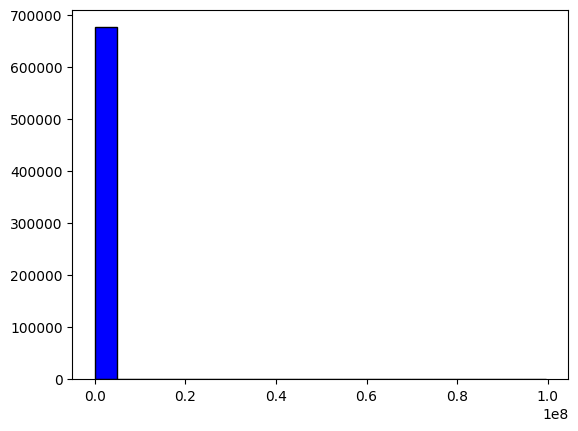

In [108]:
# Histograma de las ventas semanales
plt.hist(df['FACTURACION_PROMEDIO'], bins=20, color ='blue', edgecolor='black')
plt.show()

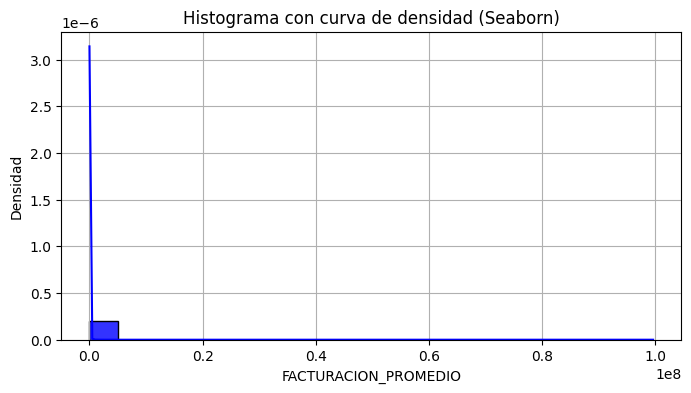

In [109]:
# Gráfico
plt.figure(figsize=(8, 4))
sns.histplot(df['FACTURACION_PROMEDIO'], bins=20, color='blue', 
             edgecolor='black', alpha=0.8, stat='density', kde=True  )
plt.title('Histograma con curva de densidad (Seaborn)')
plt.xlabel('FACTURACION_PROMEDIO')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

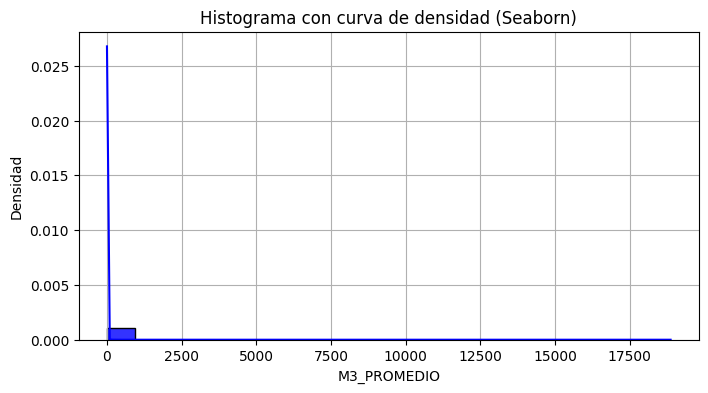

In [110]:
# Gráfico
plt.figure(figsize=(8, 4))
sns.histplot(df['M3_PROMEDIO'], bins=20, color='blue', 
             edgecolor='black', alpha=0.8, stat='density', kde=True  )
plt.title('Histograma con curva de densidad (Seaborn)')
plt.xlabel('M3_PROMEDIO')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

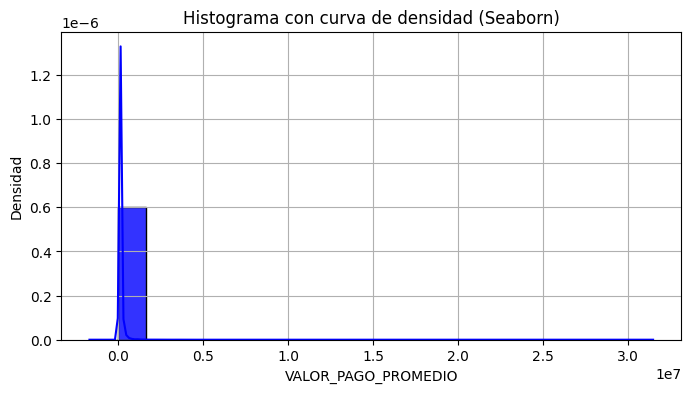

In [111]:
# Gráfico
plt.figure(figsize=(8, 4))
sns.histplot(df['VALOR_PAGO_PROMEDIO'], bins=20, color='blue', 
             edgecolor='black', alpha=0.8, stat='density', kde=True  )
plt.title('Histograma con curva de densidad (Seaborn)')
plt.xlabel('VALOR_PAGO_PROMEDIO')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

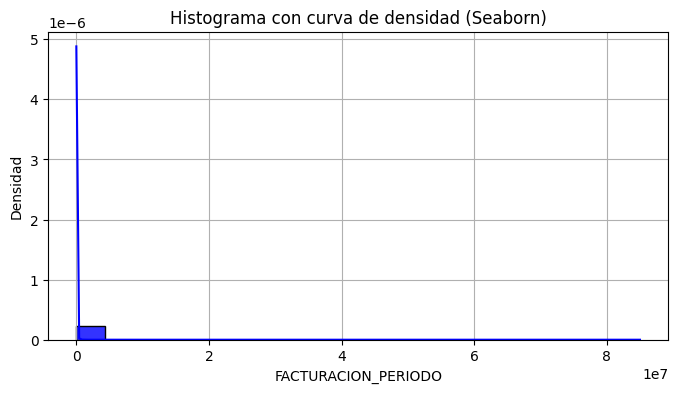

In [112]:
# Gráfico
plt.figure(figsize=(8, 4))
sns.histplot(df['FACTURACION_PERIODO'], bins=20, color='blue', 
             edgecolor='black', alpha=0.8, stat='density', kde=True  )
plt.title('Histograma con curva de densidad (Seaborn)')
plt.xlabel('FACTURACION_PERIODO')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

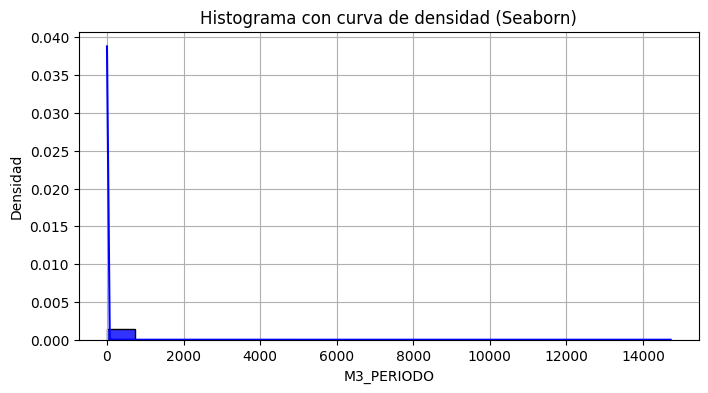

In [113]:
# Gráfico
plt.figure(figsize=(8, 4))
sns.histplot(df['M3_PERIODO'], bins=20, color='blue', 
             edgecolor='black', alpha=0.8, stat='density', kde=True  )
plt.title('Histograma con curva de densidad (Seaborn)')
plt.xlabel('M3_PERIODO')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

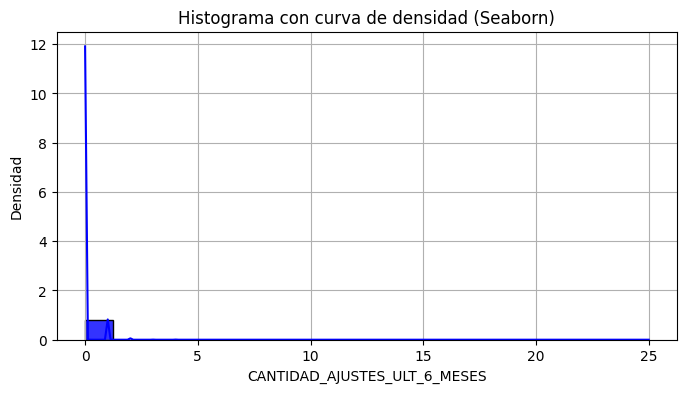

In [114]:
# Gráfico
plt.figure(figsize=(8, 4))
sns.histplot(df['CANTIDAD_AJUSTES_ULT_6_MESES'], bins=20, color='blue', 
             edgecolor='black', alpha=0.8, stat='density', kde=True  )
plt.title('Histograma con curva de densidad (Seaborn)')
plt.xlabel('CANTIDAD_AJUSTES_ULT_6_MESES')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

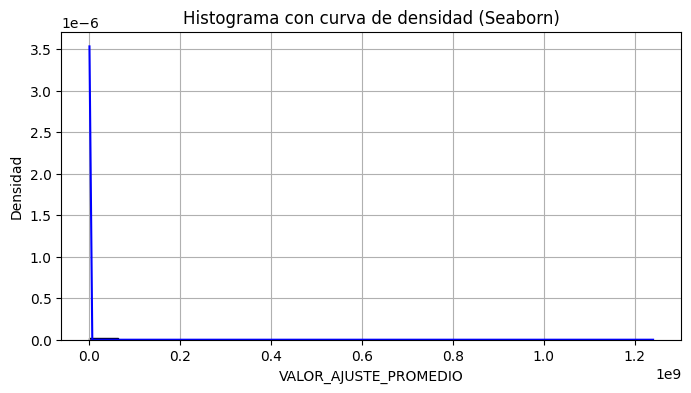

In [115]:
# Gráfico
plt.figure(figsize=(8, 4))
sns.histplot(df['VALOR_AJUSTE_PROMEDIO'], bins=20, color='blue', 
             edgecolor='black', alpha=0.8, stat='density', kde=True  )
plt.title('Histograma con curva de densidad (Seaborn)')
plt.xlabel('VALOR_AJUSTE_PROMEDIO')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

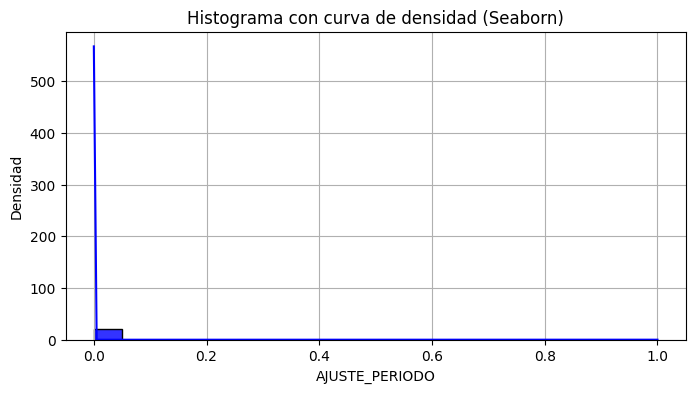

In [116]:
# Gráfico
plt.figure(figsize=(8, 4))
sns.histplot(df['AJUSTE_PERIODO'], bins=20, color='blue', 
             edgecolor='black', alpha=0.8, stat='density', kde=True  )
plt.title('Histograma con curva de densidad (Seaborn)')
plt.xlabel('AJUSTE_PERIODO')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

**Valores negativos y Outliers**

In [117]:
variables_numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

resultado = []

for col in variables_numericas:
    serie = df[col].dropna()

    # Negativos
    negativos = (serie < 0).sum()

    # Outliers por IQR
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = (
        (serie < limite_inferior) |
        (serie > limite_superior)
    ).sum()

    resultado.append({'Variable': col,
                      'Negativos': negativos,
                      '% Negativos': round(100 * negativos / len(serie), 2),
                      'Outliers': outliers,
                      '% Outliers': round(100 * outliers / len(serie), 2)})

reporte_outliers = pd.DataFrame(resultado)

reporte_outliers = reporte_outliers.sort_values(
    ['% Outliers', '% Negativos'],
    ascending=False)

display(reporte_outliers)

,Variable,Negativos,% Negativos,Outliers,% Outliers
7,VALOR_AJUSTE_PROMEDIO,0,0.00,53798,7.94
9,AJUSTE_EN_ULT_6_MESES,0,0.00,50594,7.47
6,CANTIDAD_AJUSTES_ULT_6_MESES,0,0.00,48492,7.16
1,FACTURACION_PROMEDIO,303,0.04,40179,5.94
4,FACTURACION_PERIODO,140,0.02,37405,5.52
3,VALOR_PAGO_PROMEDIO,32,0.00,33410,4.93
2,M3_PROMEDIO,0,0.00,17770,2.62
5,M3_PERIODO,0,0.00,16040,2.37
8,AJUSTE_PERIODO,0,0.00,72,0.01
0,CUENTA,0,0.00,0,0.00


Convertir negativos a 0

In [118]:
df['FACTURACION_PROMEDIO'] = np.where(df['FACTURACION_PROMEDIO'] < 0, 0,
                                      df['FACTURACION_PROMEDIO'])

df['FACTURACION_PERIODO'] = np.where(df['FACTURACION_PERIODO'] < 0, 0,
                                     df['FACTURACION_PERIODO'])

df['VALOR_PAGO_PROMEDIO'] = np.where(df['VALOR_PAGO_PROMEDIO'] < 0, 0,
                                     df['VALOR_PAGO_PROMEDIO'])

In [119]:
print(f"Negativos en FACTURACION_PROMEDIO: {(df['FACTURACION_PROMEDIO'] < 0).sum().sum()}")
print(f"Negativos en FACTURACION_PERIODO: {(df['FACTURACION_PERIODO'] < 0).sum().sum()}")
print(f"Negativos en VALOR_PAGO_PROMEDIO: {(df['VALOR_PAGO_PROMEDIO'] < 0).sum().sum()}")

Negativos en FACTURACION_PROMEDIO: 0
Negativos en FACTURACION_PERIODO: 0
Negativos en VALOR_PAGO_PROMEDIO: 0


**ANÁLISIS BIVARIADO**

* H0: Facturación_promedio es igual en ajuste_6_meses
* H1: Facturación_promedio es diferente en ajuste_6_meses

In [120]:
#Estadísticos descriptivos por grupo
df.groupby('AJUSTE_EN_ULT_6_MESES')['FACTURACION_PROMEDIO'].describe()

,count,mean,std,min,25%,50%,75%,max
AJUSTE_EN_ULT_6_MESES,,,,,,,,
0,625841.0,63596.378756,139971.742320,0.0,30126.670,49410.830,74231.500,50842636.83
1,50576.0,88135.414708,589696.478933,0.0,35743.545,55535.835,83210.085,99603114.83


In [121]:
#Mediana y desviación estándar por grupo
df.groupby('AJUSTE_EN_ULT_6_MESES')['FACTURACION_PROMEDIO'].agg(['count',
                                                                 'median',
                                                                 'mean',
                                                                 'std'])

,count,median,mean,std
AJUSTE_EN_ULT_6_MESES,,,,
0,625841,49410.830,63596.378756,139971.742320
1,50576,55535.835,88135.414708,589696.478933


In [122]:
#Quartiles
df.groupby('AJUSTE_EN_ULT_6_MESES')['FACTURACION_PROMEDIO'].quantile(
    [0.25,0.50,0.75,0.90,0.95]).unstack()

,0.25,0.50,0.75,0.90,0.95
AJUSTE_EN_ULT_6_MESES,,,,,
0,30126.670,49410.830,74231.500,111471.50,149437.00
1,35743.545,55535.835,83210.085,134454.17,190288.04


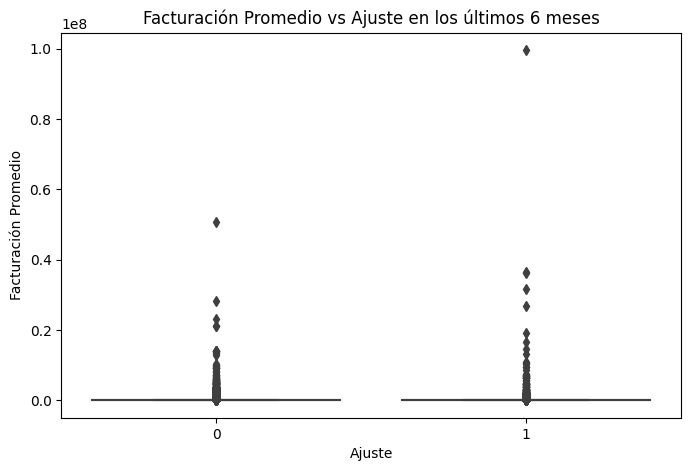

In [123]:
#Boxplot de FACTURACION_PROMEDIO por AJUSTE_EN_ULT_6_MESES

plt.figure(figsize=(8,5))

sns.boxplot(
    x='AJUSTE_EN_ULT_6_MESES',
    y='FACTURACION_PROMEDIO',
    data=df
)

plt.title('Facturación Promedio vs Ajuste en los últimos 6 meses')
plt.xlabel('Ajuste')
plt.ylabel('Facturación Promedio')

plt.show()

**VARIABLES CATEGORICAS**

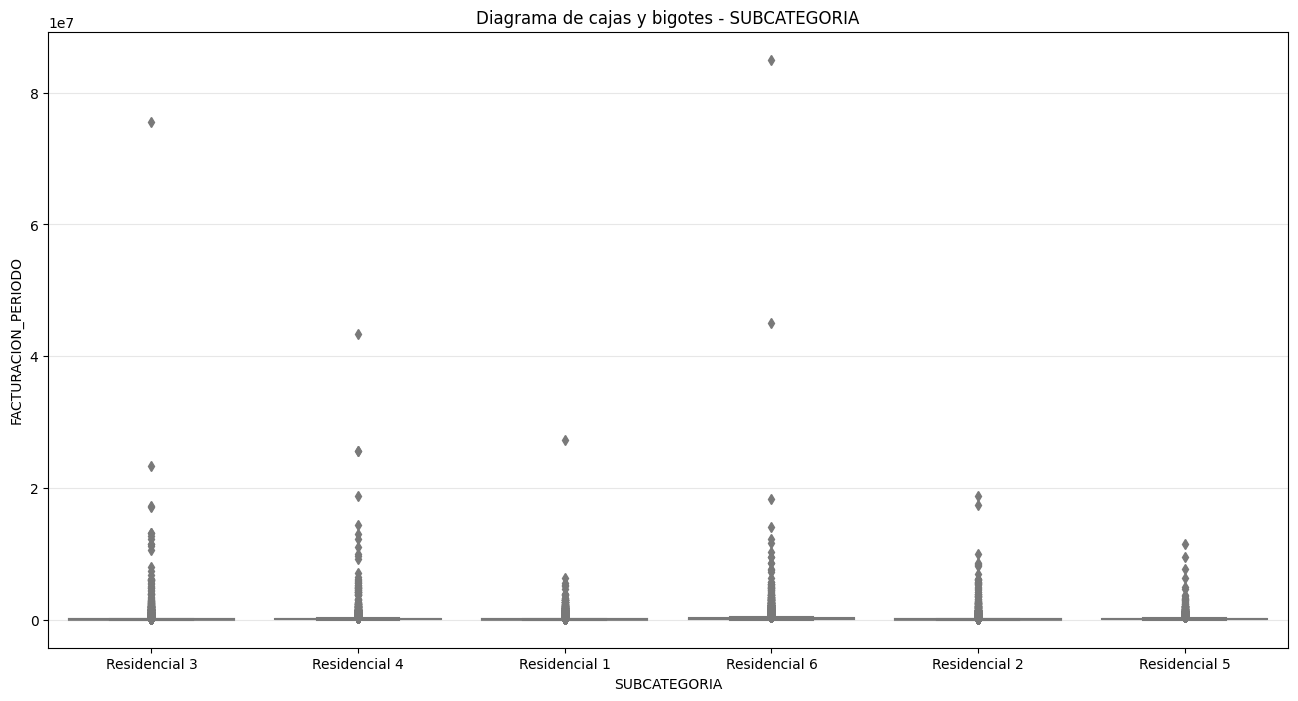

In [124]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    x='SUBCATEGORIA',
    y='FACTURACION_PERIODO',
    data=df,
    color='lightblue'
)

plt.title('Diagrama de cajas y bigotes - SUBCATEGORIA')
plt.ylabel('FACTURACION_PERIODO')

plt.grid(True, axis='y', alpha=0.3)

plt.show()

**Asimetría de Facturación periodo**

In [125]:
print(f"Coeficiente de asimetría: {df['FACTURACION_PROMEDIO'].skew()}") #Coeficienre de asimetría
print(f"Curtosis: {df['FACTURACION_PERIODO'].kurtosis()}") #Curtosis

Coeficiente de asimetría: 220.83627357594804
Curtosis: 59245.239027756645


**Prueba normalidad**

In [126]:
#Prueba de Shapiro-Wilk para normalidad
muestra = df['FACTURACION_PROMEDIO'].dropna().sample(
    min(5000, len(df)),
    random_state=42)

print(shapiro(muestra))

ShapiroResult(statistic=0.20183563232421875, pvalue=0.0)


Los datos no siguen una distribución normal, por lo que se recomienda aplicar una transformación logarítmica para mejorar la normalidad de los datos.

Asimetría: indica una cola derecha gigantesca. Hay observaciones mucho mayores que la mayoría de los registros. No es 0

Curtosis: sugiere presencia de valores extremos muy alejados del resto. No es 0, lo ideal es que sea menor a 2.

Shapiro: p-value = 0.0

Hipótesis:
H0: la variable sigue una distribución normal.
H1: la variable no sigue una distribución normal.

Como: p < 0.05
se rechaza H0. No sigue una distribución normal

1. Histograma
2. Boxplot normal
3. Skewness y Kurtosis
4. Prueba de normalidad
5. Boxplot logarítmico para interpretar mejor
6. Pruebas no paramétricas (Mann-Whitney, Kruskal-Wallis, Spearman)

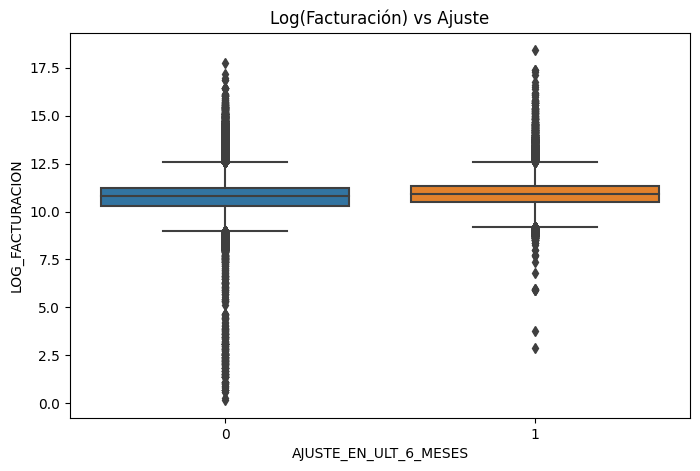

In [127]:
df_aux = df[df['FACTURACION_PROMEDIO'] > 0].copy()

df_aux['LOG_FACTURACION'] = np.log1p(
    df_aux['FACTURACION_PROMEDIO'])

plt.figure(figsize=(8,5))

sns.boxplot(
    x='AJUSTE_EN_ULT_6_MESES',
    y='LOG_FACTURACION',
    data=df_aux)

plt.title('Log(Facturación) vs Ajuste')
plt.show()

**Se aplica transformación logarítmica**

In [128]:
df['FACTURACION_LOG'] = np.log1p(df['FACTURACION_PROMEDIO'])

**Verificar prueba de Shapiro nuevamente**

In [129]:
x = df['FACTURACION_LOG'].dropna()

print("Asimetría:", skew(x))
print("Curtosis:", kurtosis(x, fisher=False))
print(shapiro(x.sample(min(5000,len(x)), random_state=42)))

Asimetría: -1.4064747377846947
Curtosis: 20.837819081378978
ShapiroResult(statistic=0.9412471055984497, pvalue=1.1073200594941137e-40)


**Notas**

Asimetría pasó de: 190  →  -1.41. Es una mejora enorme.

Ahora la distribución tiene una asimetría moderada hacia la izquierda.

Curtosis pasó de: 59.245  →  20.84. También mejoró drásticamente.

Sin embargo: Curtosis normal ≈ 3

Todavía existen colas pesadas y/o valores extremos.

| Valor de Skewness | Interpretación         |
| ----------------- | ---------------------- |
| 0                 | Simétrica              |
| ±0.5              | Leve                   |
| ±1                | Moderada               |
| > ±2              | Muy alta               |
| **140**           | Extremadamente anormal |

| Kurtosis   | Interpretación                             |
| ---------- | ------------------------------------------ |
| 0          | Normal                                     |
| 3-10       | Colas pesadas                              |
| > 20       | Muy extrema                                |
| **29,018** | Distribución dominada por valores extremos |


La variable FACTURACION_LOG presenta una mejora sustancial respecto a la variable original, reduciendo significativamente la asimetría y la curtosis. Sin embargo, la prueba de Shapiro-Wilk continúa rechazando la hipótesis de normalidad (p < 0.05), indicando que la distribución aún se desvía de una normal. Debido al gran tamaño de la muestra, esta desviación puede ser estadísticamente significativa aunque no necesariamente relevante desde el punto de vista práctico.

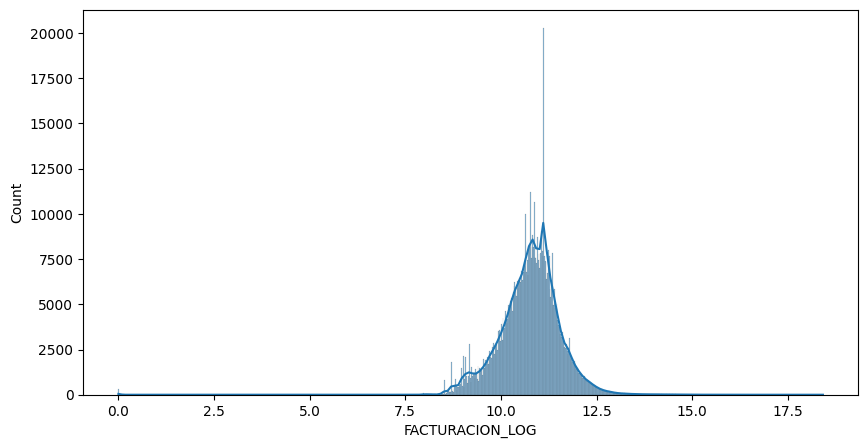

In [130]:
plt.figure(figsize=(10,5))
sns.histplot(df['FACTURACION_LOG'], kde=True)
plt.show()

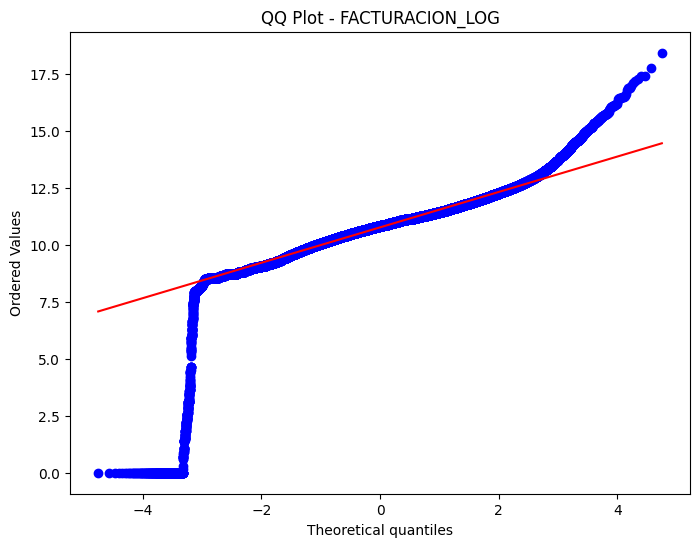

In [131]:
plt.figure(figsize=(8,6))

stats.probplot(
    df['FACTURACION_LOG'].dropna(), dist="norm", plot=plt)

plt.title("QQ Plot - FACTURACION_LOG")
plt.show()

En este gráfico:

Parte central bastante alineada
Entre los cuantiles aproximadamente -2 y 2 los puntos siguen relativamente bien la línea.
Esto indica que la mayor parte de los registros tiene un comportamiento cercano a una distribución simétrica.

Desviación fuerte en la cola izquierda

Hay una especie de "pared vertical" cerca de los cuantiles -3.
Esto suele ocurrir cuando existen muchos valores iguales o cercanos a cero.
Como usaste log1p(), es muy probable que muchos registros tengan:
FACTURACION_PERIODO = 0

y por tanto:

log1p(0) = 0

Desviación fuerte en la cola derecha

Los puntos se elevan por encima de la línea roja.
Esto indica que aún existen observaciones extremadamente grandes.
Es consistente con los percentiles que mostraste:
P99.9 = 1.446.195
Máx = 85.010.330

In [132]:
df['FACTURACION_PERIODO'].describe(percentiles=[
    .50,.75,.90,.95,.99,.995,.999]).T

count    6.775070e+05
mean     6.430605e+04
std      2.206644e+05
min      0.000000e+00
50%      4.817200e+04
75%      7.588400e+04
90%      1.170014e+05
95%      1.582980e+05
99%      3.131701e+05
99.5%    4.368707e+05
99.9%    1.291297e+06
max      8.501033e+07
Name: FACTURACION_PERIODO, dtype: float64

In [133]:
df[['FACTURACION_PERIODO']].sort_values(
    by='FACTURACION_PERIODO',
    ascending=False).head(20)

,FACTURACION_PERIODO
3,85010329
0,75625702
12,45006794
4,43448126
2,27299245
14,25544384
15,25544384
7,23329388
16,18740938
17,18728277
